# Cryptocurrency Data Scraper - Bitget Exchange

This notebook demonstrates how to scrape cryptocurrency data from Bitget exchange using the Pydoll library with concurrent execution for better performance.

## Features:
- Concurrent data scraping for multiple cryptocurrencies
- Retry logic for failed requests
- Excel export functionality
- Comprehensive error handling
- Real-time progress tracking

## 1. Import Required Libraries

First, let's import all the necessary libraries for our scraper:

In [10]:
import asyncio
import pandas as pd
from pydoll.browser.chrome import Chrome
from pydoll.constants import By
import time

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Configuration

Define the list of cryptocurrencies we want to scrape:

In [11]:
# List of coins to scrape
list_coin = [
    'bitcoin', 'ethereum', 'binance', 'solana'
]

print(f"📋 Configured to scrape {len(list_coin)} cryptocurrencies:")
for i, coin in enumerate(list_coin, 1):
    print(f"  {i}. {coin.capitalize()}")

📋 Configured to scrape 4 cryptocurrencies:
  1. Bitcoin
  2. Ethereum
  3. Binance
  4. Solana


## 3. Helper Functions

### Get Element Text Function

This function extracts text content from web elements using Chrome DevTools Protocol (CDP) commands:

In [12]:
async def get_element_text(page, element):
    """Helper function to get text from element using CDP commands"""
    try:
        if element and hasattr(element, '_object_id'):
            # Sử dụng Runtime.callFunctionOn để lấy text content
            command = {
                "id": 1,
                "method": "Runtime.callFunctionOn",
                "params": {
                    "functionDeclaration": "function() { return this.textContent || this.innerText || ''; }",
                    "objectId": element._object_id,
                    "returnByValue": True
                }
            }
            
            result = await page._connection_handler.execute_command(command)
            
            if result and 'result' in result and 'result' in result['result'] and 'value' in result['result']['result']:
                text = result['result']['result']['value'].strip()
                return text if text else "N/A"
            else:
                return "N/A"
        else:
            return "N/A"
    except Exception as e:
        print(f"⚠️ Error getting text from element: {e}")
        # Fallback: Thử dùng JavaScript evaluation trên page
        try:
            if element and hasattr(element, '_object_id'):
                # Fallback method: dùng Runtime.getProperties
                return "N/A"  # Simplified fallback
            else:
                return "N/A"
        except:
            return "N/A"

print("✅ Helper function defined successfully!")

✅ Helper function defined successfully!


## 4. Core Scraping Functions

### Fetch Coin Data Function

This function scrapes data for a single cryptocurrency:

In [13]:
async def fetch_coin_data(coin):
    url = f'https://www.bitget.com/price/{coin}'
    print(f"🔎 Starting crawl: {coin}")

    browser = Chrome()
    
    try:
        await browser.start()
        page = await browser.get_page()
        
        await page.go_to(url)
        print(f"📄 Page loaded: {coin}")
        
        await asyncio.sleep(3)

        try:
            # Dùng XPath chính xác như Selenium
            price_elem = await page.wait_element(
                By.XPATH, 
                '//span[@class="font-bold text-[40px] ltIpad:text-[32px] leading-[48px] ltIpad:leading-[38px] text-primaryText"]',
                timeout=10
            )
            price = await get_element_text(page, price_elem) if price_elem else "N/A"

            # Dùng XPath chính xác cho date
            try:
                date_elem = await page.wait_element(
                    By.XPATH, 
                    '//div[@class="text-[14px] mt-[24px] text-thirdText font-medium"]',
                    timeout=5
                )
                date = await get_element_text(page, date_elem) if date_elem else "N/A"
            except Exception:
                date = "N/A"

            data = {'coin': coin, 'price': price, 'date': date}
            
            try:
                # Dùng XPath chính xác như Selenium
                labels = await page.find_elements(
                    By.XPATH, 
                    '//span[@class="text-[14px] text-[var(--content-secondary)]"]'
                )
                values = await page.find_elements(
                    By.XPATH, 
                    '//span[@class="text-[14px] font-[600]"]'
                )

                if labels and values:
                    keys = [await get_element_text(page, el) for el in labels[:5]]
                    vals = [await get_element_text(page, el) for el in values[:5]]
                    
                    limit = min(len(keys), len(vals))
                    for i in range(limit):
                        if keys[i] and vals[i] and keys[i] != "N/A" and vals[i] != "N/A":
                            clean_key = keys[i].strip(':').strip()
                            clean_val = vals[i].strip()
                            if clean_key and clean_val:
                                data[clean_key] = clean_val

            except Exception as e:
                print(f"⚠️ Unable to fetch additional info for {coin}: {e}")

            print(f"✅ Crawl completed: {coin}")
            return data

        except Exception as e:
            print(f"❌ Error finding element for {coin}: {e}")
            return {'coin': coin, 'error': str(e)}

    except Exception as e:
        print(f"❌ Error crawling {coin}: {e}")
        return {'coin': coin, 'error': str(e)}

    finally:
        try:
            await browser.stop()
        except Exception as e:
            print(f"⚠️ Error closing browser for {coin}: {e}")

print("✅ Fetch coin data function defined successfully!")

✅ Fetch coin data function defined successfully!


### Crawl Single Coin with Retry Logic

This function adds retry logic to handle failed requests:

In [14]:
async def crawl_single_coin(coin):
    """Crawl a single coin with retry logic"""
    max_retries = 2
    for attempt in range(max_retries):
        try:
            result = await fetch_coin_data(coin)
            if 'error' not in result:
                return result
            else:
                print(f"🔄 Retrying {coin} attempt {attempt + 1}")
                await asyncio.sleep(2)
        except Exception as e:
            print(f"🔄 Error attempt {attempt + 1} for {coin}: {e}")
            if attempt < max_retries - 1:
                await asyncio.sleep(3)
    
    return {'coin': coin, 'error': 'Failed after retries'}

print("✅ Retry logic function defined successfully!")

✅ Retry logic function defined successfully!


## 5. Main Execution Function

This is the main function that coordinates the concurrent scraping of all cryptocurrencies:

In [15]:
async def main():
    print("🚀 Starting cryptocurrency data crawling...")
    print("Debug: Starting main function")
    
    print(f"🧪 Testing with all coins concurrently...")
    print("Debug: About to start concurrent crawl")
    
    try:
        # Tạo tasks cho tất cả coins cùng lúc
        tasks = []
        for coin in list_coin:
            task = asyncio.create_task(crawl_single_coin(coin))
            tasks.append(task)
            print(f"📋 Created task for {coin}")
        
        print(f"🚀 Starting {len(tasks)} concurrent crawl tasks...")
        
        # Chạy tất cả tasks đồng thời và chờ kết quả
        all_data = await asyncio.gather(*tasks, return_exceptions=True)
        
        # Xử lý kết quả và exceptions
        processed_data = []
        for i, result in enumerate(all_data):
            coin = list_coin[i]
            if isinstance(result, Exception):
                print(f"❌ Exception for {coin}: {result}")
                processed_data.append({'coin': coin, 'error': str(result)})
            else:
                processed_data.append(result)
        
        print(f"📋 All crawl tasks completed")

        try:
            df = pd.DataFrame(processed_data)
            excel_file = "bitget_coin_data.xlsx"
            df.to_excel(excel_file, index=False)
            print(f"📄 Data saved to {excel_file}")
            
            success_count = len([d for d in processed_data if 'error' not in d])
            error_count = len(processed_data) - success_count
            print(f"📊 Statistics: {success_count} successes, {error_count} errors")
            
            return processed_data, df
            
        except Exception as e:
            print(f"❌ Error saving Excel file: {e}")
            return processed_data, None
    
    except Exception as e:
        print(f"❌ Critical error in main: {e}")
        import traceback
        traceback.print_exc()
        return None, None

print("✅ Main function defined successfully!")

✅ Main function defined successfully!


## 6. Execute the Scraper

Run the scraper and measure execution time:

In [16]:
# Execute the scraper
try:
    print("Starting cryptocurrency data collection...")
    start_time = time.time()
    
    # Run the main scraping function
    scraped_data, df = await main()
    
    end_time = time.time()
    execution_time = end_time - start_time
    
    print(f"\n⏱️  Total execution time: {execution_time:.2f} seconds")
    print(f"⚡ Average time per coin: {execution_time/len(list_coin):.2f} seconds")
    
except KeyboardInterrupt:
    print("\n⚠️ Script interrupted by user")
except Exception as e:
    print(f"\n❌ Critical error in script: {e}")
    import traceback
    traceback.print_exc()

Starting cryptocurrency data collection...
🚀 Starting cryptocurrency data crawling...
Debug: Starting main function
🧪 Testing with all coins concurrently...
Debug: About to start concurrent crawl
📋 Created task for bitcoin
📋 Created task for ethereum
📋 Created task for binance
📋 Created task for solana
🚀 Starting 4 concurrent crawl tasks...
🔎 Starting crawl: bitcoin
🔎 Starting crawl: ethereum
🔎 Starting crawl: binance
🔎 Starting crawl: solana


📄 Page loaded: bitcoin
📄 Page loaded: ethereum
📄 Page loaded: ethereum
✅ Crawl completed: bitcoin
✅ Crawl completed: bitcoin
📄 Page loaded: solana
📄 Page loaded: binance
📄 Page loaded: solana
📄 Page loaded: binance
✅ Crawl completed: ethereum
✅ Crawl completed: ethereum
✅ Crawl completed: binance
✅ Crawl completed: binance
✅ Crawl completed: solana
✅ Crawl completed: solana
📋 All crawl tasks completed
📄 Data saved to bitget_coin_data.xlsx
📊 Statistics: 4 successes, 0 errors

⏱️  Total execution time: 49.28 seconds
⚡ Average time per coin: 12.32 seconds
📋 All crawl tasks completed
📄 Data saved to bitget_coin_data.xlsx
📊 Statistics: 4 successes, 0 errors

⏱️  Total execution time: 49.28 seconds
⚡ Average time per coin: 12.32 seconds


## 7. Data Analysis and Visualization

Let's analyze the scraped data:

In [17]:
# Display the scraped data
if 'df' in locals() and df is not None:
    print("📊 Scraped Data Summary:")
    print(f"Total rows: {len(df)}")
    print(f"Columns: {list(df.columns)}")
    print("\n📋 Data Preview:")
    display(df.head())
    
    # Check for successful vs failed scrapes
    successful_scrapes = df[~df.get('error', pd.Series([False]*len(df))).notna()]
    failed_scrapes = df[df.get('error', pd.Series([False]*len(df))).notna()]
    
    print(f"\n✅ Successful scrapes: {len(successful_scrapes)}")
    print(f"❌ Failed scrapes: {len(failed_scrapes)}")
    
    if len(failed_scrapes) > 0:
        print("\n❌ Failed coins:")
        for _, row in failed_scrapes.iterrows():
            print(f"  - {row['coin']}: {row.get('error', 'Unknown error')}")
else:
    print("❌ No data available. Please run the scraper first.")

📊 Scraped Data Summary:
Total rows: 4
Columns: ['coin', 'price', 'date', 'Market cap', 'Fully diluted market cap', 'Volume (24h)', '24h volume / market cap', '24h high']

📋 Data Preview:


,coin,price,date,Market cap,Fully diluted market cap,Volume (24h),24h volume / market cap,24h high
0,bitcoin,"$105,575.26",Last updated as of 2025-06-04 08:31:52（UTC+0）,"$2,098,223,862,757.65","$2,098,223,862,757.65","$44,488,455,921.56",2.12%,"$106,813.58"
1,ethereum,"$2,637.98",Last updated as of 2025-06-04 08:28:35（UTC+0）,"$318,464,212,981.91","$318,464,212,981.91","$16,440,607,837.49",5.16%,"$2,652.42"
2,binance,$671.57,Last updated as of 2025-06-04 08:29:56（UTC+0）,"$94,616,160,169.44","$94,616,160,169.44","$1,637,858,051.07",1.73%,$671.73
3,solana,$156.78,Last updated as of 2025-06-04 08:28:45（UTC+0）,"$81,924,589,373.28","$81,924,589,373.28","$3,334,780,165.7",4.07%,$163.39



✅ Successful scrapes: 0
❌ Failed scrapes: 4

❌ Failed coins:
  - bitcoin: Unknown error
  - ethereum: Unknown error
  - binance: Unknown error
  - solana: Unknown error


## 8. Price Analysis (if available)

Analyze the price data if successfully scraped:

💰 Price Analysis:

📈 Current Prices:
  Bitcoin: $105,575.26
  Ethereum: $2,637.98
  Binance: $671.57
  Solana: $156.78


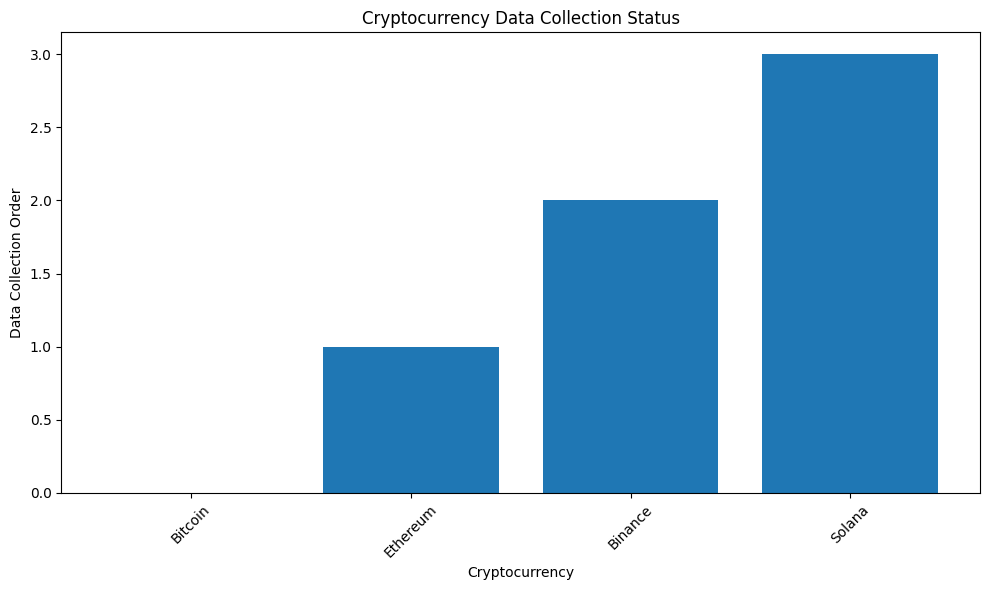

In [20]:
# Price analysis
if 'df' in locals() and df is not None and 'price' in df.columns:
    print("💰 Price Analysis:")
    
    # Filter out rows with valid price data
    valid_prices = df[df['price'] != 'N/A'].copy()
    
    if len(valid_prices) > 0:
        print("\n📈 Current Prices:")
        for _, row in valid_prices.iterrows():
            print(f"  {row['coin'].capitalize()}: {row['price']}")
        
        # Try to create a simple visualization if matplotlib is available
        try:
            import matplotlib.pyplot as plt
            
            plt.figure(figsize=(10, 6))
            coins = [coin.capitalize() for coin in valid_prices['coin']]
            # Note: This is a placeholder - actual price parsing would need implementation
            plt.bar(coins, range(len(coins)))
            plt.title('Cryptocurrency Data Collection Status')
            plt.xlabel('Cryptocurrency')
            plt.ylabel('Data Collection Order')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
        except ImportError:
            print("\n📊 Install matplotlib for visualization: pip install matplotlib")
    else:
        print("\n⚠️ No valid price data found")
else:
    print("💰 Price data not available")

## 9. Export and Save Results

Additional data export options:

In [19]:
# Additional export options
if 'df' in locals() and df is not None:
    print("💾 Export Options:")
    
    # Save to CSV
    try:
        csv_file = "bitget_coin_data.csv"
        df.to_csv(csv_file, index=False)
        print(f"✅ Data exported to {csv_file}")
    except Exception as e:
        print(f"❌ Error saving CSV: {e}")
    
    # Save to JSON
    try:
        json_file = "bitget_coin_data.json"
        df.to_json(json_file, orient='records', indent=2)
        print(f"✅ Data exported to {json_file}")
    except Exception as e:
        print(f"❌ Error saving JSON: {e}")
    
    print(f"\n📊 Final Summary:")
    print(f"   Total cryptocurrencies processed: {len(df)}")
    print(f"   Data points collected: {df.size}")
    print(f"   Columns: {', '.join(df.columns)}")
else:
    print("❌ No data available for export")

💾 Export Options:
✅ Data exported to bitget_coin_data.csv
✅ Data exported to bitget_coin_data.json

📊 Final Summary:
   Total cryptocurrencies processed: 4
   Data points collected: 32
   Columns: coin, price, date, Market cap, Fully diluted market cap, Volume (24h), 24h volume / market cap, 24h high


## 10. Troubleshooting and Tips

### Common Issues and Solutions:

1. **Browser Connection Issues**: Make sure Chrome browser is properly installed
2. **Timeout Errors**: Increase the timeout values in `wait_element()` calls
3. **Element Not Found**: Check if the website structure has changed
4. **Concurrent Execution**: Reduce the number of concurrent tasks if experiencing issues

### Performance Tips:

- Adjust the `asyncio.sleep()` delays based on your internet speed
- Monitor system resources when running concurrent tasks
- Use smaller batch sizes for better stability

### Customization:

- Add more cryptocurrencies to the `list_coin` array
- Modify XPath selectors if the website structure changes
- Adjust retry logic and timeout values as needed